In [1]:
from shopping_assistant.env import load_env

load_env()

True

In [2]:
from openai import OpenAI

In [3]:
openai_client = OpenAI()

### Basic Router Agent

In [5]:
DOWNSTREAM_ROUTES = [
    {
        "name": "product_search",
        "description": "Helps the user find products in the catalog based on the product name or description.",
        "examples":
        [
            "I am looking for headphones under 2000 rupees.",
            "Do you have wind cheaters in red and white colour?",
            "I want to buy a new laptop.",
            "Can you give me some options for phones with good camera?",
        ]
    },

    {
        "name": "shopping_actions",
        "description": "Helps the user perform shopping actions such as shoppingcart interaction, order placement, checkout, cancellation etc",
        "examples":
        [
            "Can you add this to the cart?",
            "Please update the quantity of hdmi cables to 2.",
            "I want to place an order for this product",
            "I want to cancel my order",
            "Can you take me to the checkout page?",
        ]
    },
    {
        "name": "customer_service",
        "description": "Helps the user with any customer service related queries or any general chit chat.",
        "examples":
        [
            "Hello!",
            "I have a complaint regarding a recent product I ordered.",
            "Can you tell me the terms and conditions for the return process?",
        ]
    }
]

DOWNSTREAM_ROUTES_LIST = [d['name'] for d in DOWNSTREAM_ROUTES]

In [6]:
DOWNSTREAM_ROUTER_INTRO_PROMPT = """You are a helpful ecom shopping assistant tasked with redirecting the user to the appropriate specialized downstream routes. The available specialized agents are:"""

def build_prompt_from_downstream_routes(
    downstream_routes, 
    intro_prompt
):
    """
    Build a prompt from the downstream routes.
    """

    routes_lst = [d['name'] for d in downstream_routes]
    prompt = intro_prompt
    prompt += f"\nThe available routes are: {routes_lst}"
    prompt += "\n\n"

    for idx, route in enumerate(downstream_routes):
        prompt += f"\n(Route {idx+1}) `{route['name']}`: {route['description']}"
        prompt += "\nExamples:"
        for idx, example in enumerate(route['examples']):
            prompt += f"\n{idx+1}: {example}"

        prompt += '\n\n'

    prompt += "Please output the appropriate route based on the user's query."
    return prompt

In [7]:
print(build_prompt_from_downstream_routes(DOWNSTREAM_ROUTES, intro_prompt=DOWNSTREAM_ROUTER_INTRO_PROMPT))

You are a helpful ecom shopping assistant tasked with redirecting the user to the appropriate specialized downstream routes. The available specialized agents are:
The available routes are: ['product_search', 'shopping_actions', 'customer_service']


(Route 1) `product_search`: Helps the user find products in the catalog based on the product name or description.
Examples:
1: I am looking for headphones under 2000 rupees.
2: Do you have wind cheaters in red and white colour?
3: I want to buy a new laptop.
4: Can you give me some options for phones with good camera?


(Route 2) `shopping_actions`: Helps the user perform shopping actions such as shoppingcart interaction, order placement, checkout, cancellation etc
Examples:
1: Can you add this to the cart?
2: Please update the quantity of hdmi cables to 2.
3: I want to place an order for this product
4: I want to cancel my order
5: Can you take me to the checkout page?


(Route 3) `customer_service`: Helps the user with any customer servic

In [8]:
SYSTEM_MESSAGE = build_prompt_from_downstream_routes(DOWNSTREAM_ROUTES, intro_prompt=DOWNSTREAM_ROUTER_INTRO_PROMPT)

In [9]:
response = openai_client.chat.completions.create( 
    model="gpt-4",
    messages=[
        {"role": "system", "content": SYSTEM_MESSAGE},
        {"role": "user", "content": "I want the new airpods pro 3 earphones"}
    ]
)

print(response.choices[0].message.content)

product_search


In [10]:
from pydantic import BaseModel

In [11]:
from typing import Literal

class DownstreamRoutesAgentResponse(BaseModel):
    route: Literal[*DOWNSTREAM_ROUTES_LIST]

In [13]:
response = openai_client.responses.parse(
    model="gpt-4o-mini",
    input=[
        {"role": "system", "content": SYSTEM_MESSAGE},
        {"role": "user", "content": "I want the new airpods pro 3 earphones"}
    ],
    text_format=DownstreamRoutesAgentResponse
)

In [14]:
response.output_parsed

DownstreamRoutesAgentResponse(route='product_search')

In [15]:
from langgraph.graph import StateGraph, add_messages, START, END


In [16]:
from typing import Annotated
from pydantic import BaseModel

class State(BaseModel):
    messages: Annotated[list, add_messages]

In [33]:
def router_agent(state: State) -> Literal[*DOWNSTREAM_ROUTES_LIST]:

    input_messages = [
        {"role": "system", "content": SYSTEM_MESSAGE},
        *state.messages[:-1],
        {"role": "user", "content": f"Route based on this message: {state.messages[-1].content}"}
    ]

    response = openai_client.responses.parse(
        model="gpt-4o-mini",
        input=input_messages,
        text_format=DownstreamRoutesAgentResponse
    )

    return response.output_parsed.route


In [34]:
def shopping_actions_agent(state: State) -> State:

    response = {
        "role": "assistant",
        "content": "The query was routed to shopping_agent"
    }

    return State(messages=[response])

def product_search_agent(state: State) -> State:

    response = {
        "role": "assistant",
        "content": "The query was routed to product_search_agent"
    }

    return State(messages=[response])


def customer_service_agent(state: State) -> State:

    response = {
        "role": "assistant",
        "content": "The query was routed to customer_service_agent"
    }

    return State(messages=[response])


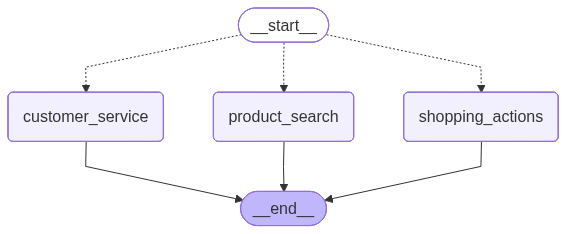

In [35]:
graph_builder = StateGraph(State)

graph_builder.add_conditional_edges(START, router_agent)
graph_builder.add_node("product_search", product_search_agent)
graph_builder.add_node("shopping_actions", shopping_actions_agent)
graph_builder.add_node("customer_service", customer_service_agent)

# graph_builder.add_edge(START, "router_agent")

graph = graph_builder.compile()
graph

In [37]:
init_state = State(
    messages=[{"role": "user", "content": "Do you have the samsung s90f in stock?"}]
)
graph.invoke(init_state)

{'messages': [HumanMessage(content='Do you have the samsung s90f in stock?', additional_kwargs={}, response_metadata={}, id='8d9d25ce-830e-4f95-8166-5f418331b65b'),
  AIMessage(content='The query was routed to product_search_agent', additional_kwargs={}, response_metadata={}, id='c8f6354b-4bce-4b7b-93d5-f3e4e47cfafd')]}